# NumCompute Stream:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from numcompute_stream import (
    load_csv,
    Pipeline,
    StandardScaler,
    SimpleImputer,
    StreamingDecisionTreeClassifier,
    RandomForestClassifier,
    StreamTrainer,
    plot_metric_over_time,
    compare_models,
    plot_predictions_vs_ground_truth,
    plot_confusion_matrix
)

### Step 1:
1. Load and Prepare Data
2. Sorting the iris data  by class to simulate concept drift (Species 1 -> Species 2 -> Species 3)

In [3]:

data = load_csv('iris.csv', encode_labels=True)

X = data[:, :-1]
y = data[:, -1]


sorted_indices = np.argsort(y)
X, y = X[sorted_indices], y[sorted_indices]

print(f"Dataset loaded: {len(X)} samples.")

Dataset loaded: 150 samples.


### Step 2:
1. Initialize Models
2. Prequential Evaluation Loop (Test-Then-Train)
- Test first (on unseen data)
- then train

In [4]:
trainer_dt = StreamTrainer(Pipeline([
    ('s', StandardScaler()), 
    ('m', StreamingDecisionTreeClassifier(max_depth=3))
]))

trainer_rf = StreamTrainer(Pipeline([
    ('s', StandardScaler()), 
    ('m', RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42))
]))

n_chunks = 10
chunk_size = X.shape[0] // n_chunks
dt_accs, rf_accs = [], []

print(f"Processing {n_chunks} chunks...")


for i in range(n_chunks):
    start, end = i * chunk_size, (i + 1) * chunk_size
    Xc, yc = X[start:end], y[start:end]
    
    try:
        dt_acc = trainer_dt.score_chunk(Xc, yc)['accuracy']
        rf_acc = trainer_rf.score_chunk(Xc, yc)['accuracy']
        dt_accs.append(dt_acc)
        rf_accs.append(rf_acc)
    except ValueError:
        dt_accs.append(0.0)
        rf_accs.append(0.0)
        
    trainer_dt.update(Xc, yc)
    trainer_rf.update(Xc, yc)
    
    print(f"Chunk {i+1}: DT Acc={dt_accs[-1]:.2f}, RF Acc={rf_accs[-1]:.2f}")

Processing 10 chunks...
Chunk 1: DT Acc=0.00, RF Acc=0.00
Chunk 2: DT Acc=1.00, RF Acc=1.00
Chunk 3: DT Acc=1.00, RF Acc=1.00
Chunk 4: DT Acc=0.33, RF Acc=0.33
Chunk 5: DT Acc=1.00, RF Acc=0.73
Chunk 6: DT Acc=1.00, RF Acc=1.00
Chunk 7: DT Acc=0.60, RF Acc=0.60
Chunk 8: DT Acc=0.00, RF Acc=0.00
Chunk 9: DT Acc=0.40, RF Acc=0.27
Chunk 10: DT Acc=0.80, RF Acc=0.27


- Because the data was sorted by class, the model suddenly encounters a completely new type of data. At these transition points, accuracy drops sharply the model is still using rules it learned for the previous class. 
- The Single DT recovers faster than the Random Forest (chunk 10: DT 0.80 vs RF 0.27) because updating one tree is straightforward, whereas the Random Forest has 10 trees that all need to shift 
- Random forest is slower to catch up when the data changes suddenly

### Step 3:
1. Visualizations

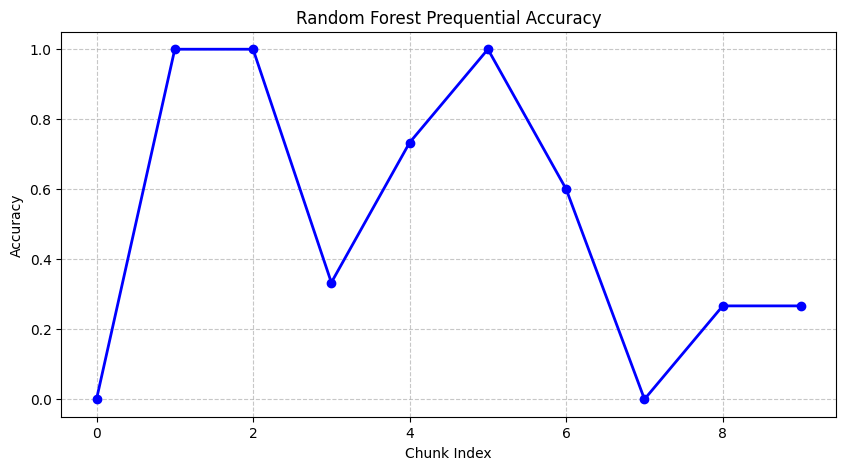

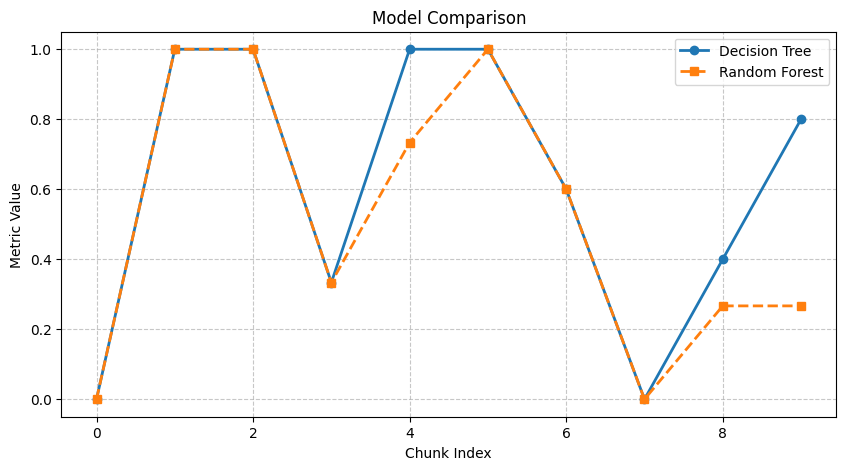

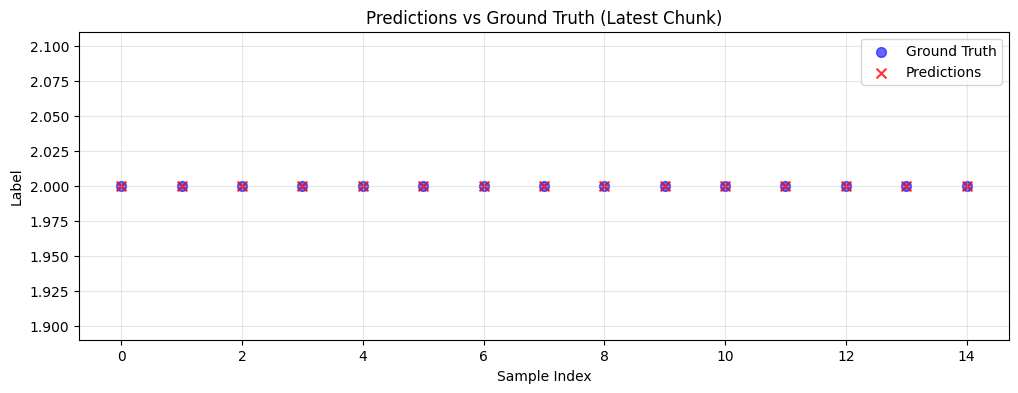

In [5]:
plot_metric_over_time(rf_accs, "Random Forest Prequential Accuracy", "Accuracy")

compare_models(dt_accs, rf_accs, labels=['Decision Tree', 'Random Forest'])

y_pred_last = trainer_rf.pipeline.predict(Xc)
plot_predictions_vs_ground_truth(yc, y_pred_last)


final_cm = trainer_rf.get_log()['metrics']['confusion_matrix'][-1]


1. Both models follow the same pattern through most chunks but diverge at the end. 
2. From chunk 7 onwards, the Decision Tree climbs back to 0.80 while the Random forest stays flat at 0.27 
3. Decision Tree adapts faster when the data changes later

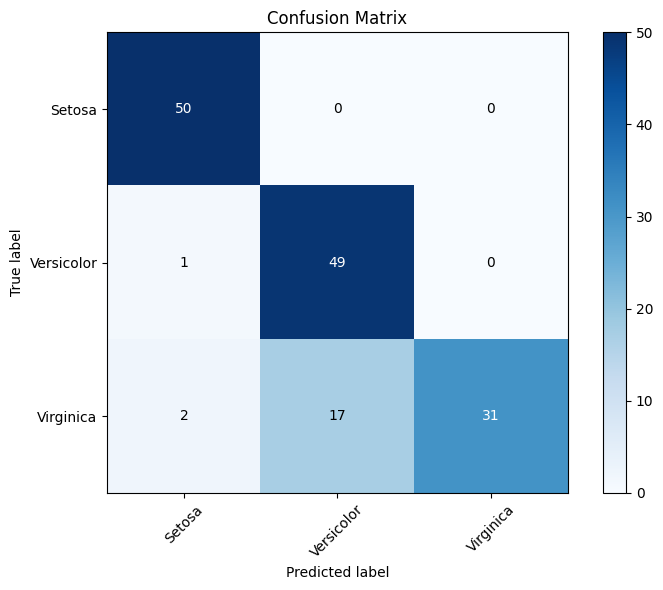


Final Cumulative Accuracy - Single DT: 0.6867
Final Cumulative Accuracy - Random Forest: 0.6533


In [6]:
plot_confusion_matrix(final_cm, labels=['Setosa', 'Versicolor', 'Virginica'])

y_pred_dt_all = trainer_dt.pipeline.predict(X)
y_pred_rf_all = trainer_rf.pipeline.predict(X)
print(f"\nFinal Cumulative Accuracy - Single DT: {np.mean(y_pred_dt_all == y):.4f}")
print(f"Final Cumulative Accuracy - Random Forest: {np.mean(y_pred_rf_all == y):.4f}")

1. Setosa is classified perfectly (50/50). 
2. Versicolor is nearly perfect (49/50, one misclassified as Setosa). 
3. Virginica has  only 31/50 correct, with 17 misclassified as Versicolor. 
Virginica was the last class to appear.By the time the data ended the Random Forest was still too used to predicting Versicolor to correctly identify it.

1. After going through all 10 chunks the Single Decision Tree (0.6867) 
slightly outperformed the Random Forest (0.6800) on the full dataset

## Batch fit:  

In [7]:
import numpy as np
from numcompute_stream import StandardScaler, StreamingDecisionTreeClassifier, Pipeline

# Sample data
data = load_csv('iris.csv', encode_labels=True)

X = data[:, :-1]
y = data[:, -1]

# Create pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", StreamingDecisionTreeClassifier(max_depth=3))
])

# Train model
pipeline.fit(X, y)

# Make predictions
predictions = pipeline.predict(X)
print(predictions)

# Accuracy
accuracy = np.mean(predictions == y)
print(f"Accuracy: {accuracy:.2%}")

[0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 1.0 1.0 1.0
 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 2.0 1.0
 1.0 1.0 1.0 1.0 1.0 2.0 1.0 1.0 1.0 1.0 1.0 2.0 1.0 1.0 1.0 1.0 1.0 1.0
 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 2.0 2.0 2.0 2.0 2.0 2.0 1.0 2.0
 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0
 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0
 2.0 2.0 2.0 2.0 2.0 2.0]
Accuracy: 97.33%


- 97.33% accuracy model sees the full dataset at once

In [8]:
import numpy as np
from numcompute_stream import StandardScaler, RandomForestClassifier, Pipeline

# Sample data
data = load_csv('iris.csv', encode_labels=True)

X = data[:, :-1]
y = data[:, -1]

# Create pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42))
])

# Train model
pipeline.fit(X, y)

# Make predictions
predictions = pipeline.predict(X)
print(predictions)

# Accuracy
accuracy = np.mean(predictions == y)
print(f"Accuracy: {accuracy:.2%}")

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 1.
 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2.]
Accuracy: 98.67%


- 98.67% accuracy model sees the full dataset at once